In [39]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sim_ranking as sr
import spatial_hazard as sh
import sha_calc as sha

In [40]:
# emp_rel_dir = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0129_100r")
# emp_rel_dir = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0129_500r")
emp_rel_dir = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0129_1000r")

db_ffp = emp_rel_dir / "gm_db_emp.sqlite"
db = sr.db.DB(db_ffp)

gen_gm_params = pd.read_csv("/Users/claudy/dev/work/data/sim_ranking/emp_gm_params/nzgmdb/emp_gm_params.csv", index_col=0)

In [41]:
site_df = db.get_site_df()
dist_matrix = sh.im_dist.calculate_distance_matrix(
    site_df.index.values.astype(str), site_df
)

In [42]:
# Load the realisations
event = "2016p118944"
site = "ADCS"

# event_sites = db.get_event_sites()
# event = np.random.choice(db.get_avail_events(), 1)[0]
# site = np.random.choice(event_sites[event], 1)[0]
print("Event: ", event)
print("Site: ", site)

cur_rel_df =  db.get_sim_data(event, [site])

Event:  2016p118944
Site:  ADCS


In [43]:
# gen_gm_params.loc[f"{event}_{site}", f"pSA_0.1_std_Total"]
# gen_gm_params.loc[f"{event}_{site}"]

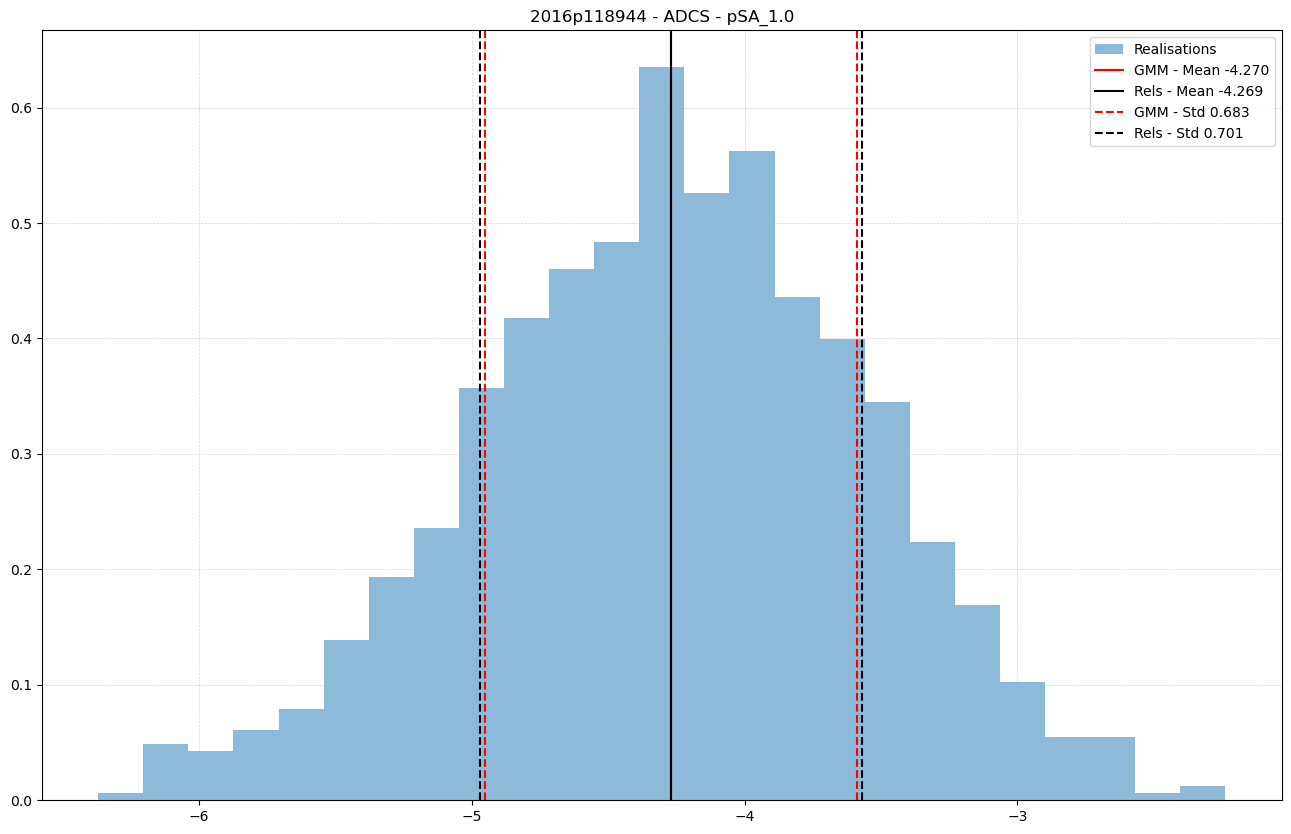

In [44]:
cur_im = "pSA_1.0"

rel_mean = np.mean(np.log(cur_rel_df[cur_im]))
rel_std = np.std(np.log(cur_rel_df[cur_im]))
gmm_mean = gen_gm_params.loc[f"{event}_{site}", f"{cur_im}_mean"]
gmm_std_total = gen_gm_params.loc[f"{event}_{site}", f"{cur_im}_std_Total"]

fig = plt.figure(figsize=(16, 10))

plt.hist(np.log(cur_rel_df[cur_im]), bins=25, density=True, alpha=0.5, label="Realisations");

plt.axvline(gmm_mean, color="red", label=f"GMM - Mean {gmm_mean:.3f}");
plt.axvline(rel_mean, color="black", label=f"Rels - Mean {rel_mean:.3f}");

plt.axvline(gmm_mean - gmm_std_total, color="red", linestyle="--", label=f"GMM - Std {gmm_std_total:.3f}");
plt.axvline(gmm_mean + gmm_std_total, color="red", linestyle="--");

plt.axvline(rel_mean - rel_std, color="black", linestyle="--", label=f"Rels - Std {rel_std:.3f}");
plt.axvline(rel_mean + rel_std, color="black", linestyle="--");

plt.title(f"{event} - {site} - {cur_im}");
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.legend();


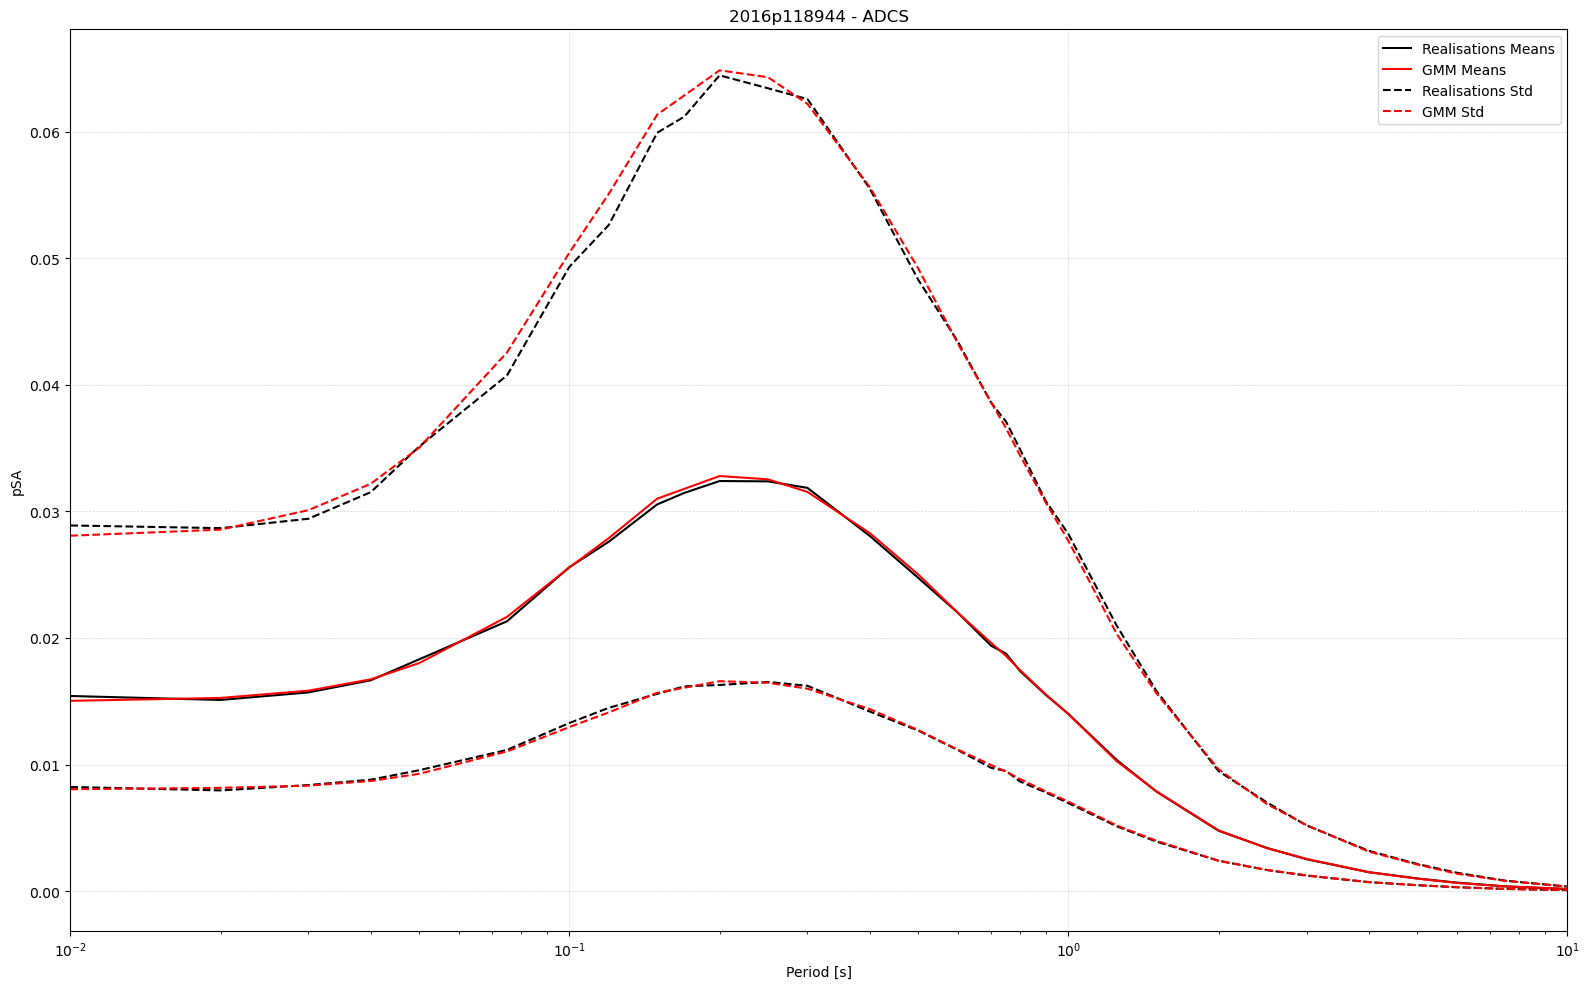

In [45]:
rel_means, rel_stds = [], []
gmm_means, gmm_stds = [], []
for cur_im in sr.constants.PSA_KEYS:
	rel_means.append(np.mean(np.log(cur_rel_df[cur_im])))
	rel_stds.append(np.std(np.log(cur_rel_df[cur_im])))
	gmm_means.append(gen_gm_params.loc[f"{event}_{site}", f"{cur_im}_mean"])
	gmm_stds.append(gen_gm_params.loc[f"{event}_{site}", f"{cur_im}_std_Total"])
	
rel_means = np.array(rel_means)
rel_stds = np.array(rel_stds)
gmm_means = np.array(gmm_means)
gmm_stds = np.array(gmm_stds)

fig = plt.figure(figsize=(16, 10))

plt.semilogx(sr.constants.PERIODS, np.exp(rel_means), label="Realisations Means", c="k");
plt.semilogx(sr.constants.PERIODS, np.exp(gmm_means), label="GMM Means", c="r");

plt.semilogx(sr.constants.PERIODS, np.exp(rel_means + rel_stds), label="Realisations Std", c="k", linestyle="--");
plt.semilogx(sr.constants.PERIODS, np.exp(rel_means - rel_stds), c="k", linestyle="--");

plt.semilogx(sr.constants.PERIODS, np.exp(gmm_means + gmm_stds), label="GMM Std", c="r", linestyle="--");
plt.semilogx(sr.constants.PERIODS, np.exp(gmm_means - gmm_stds), c="r", linestyle="--");

plt.title(f"{event} - {site}");
plt.xlabel(f"Period [s]")
plt.ylabel(f"pSA")
plt.xlim(0.01, 10)
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.legend()
plt.tight_layout()

In [46]:
def plot_corr(corr_df, dist_matrix, mask):
	fig, ax = plt.subplots(figsize=(16, 10))
	ax.scatter(
	    cur_dist_matrix.values[mask],
	    corr_df.values[mask],
	    s=1.5,
	    c="b",
	    label="MERA"
	)
	
	dist = np.linspace(0, 300, 1000)
	loth_baker_vals = sha.loth_baker_corr_model.get_correlations(cur_im, cur_im, dist)
	ax.plot(dist, loth_baker_vals, c="k", linewidth=1.0)
	
	ax.set_xlabel(f"Distance (km)")
	ax.set_ylabel(f"Site-Correlation")
	ax.set_ylim(-1.0, 1.0)
	ax.set_xlim(0.0, 100)
	ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	ax.legend()
	fig.tight_layout()

In [47]:
## Config for correlation calculation
cur_im = "pSA_1.0"

## MERA Approach for spatial correlation calculation
Treats each realisation as an independent event, i.e. computes a between- and within-event term for each realisation.

In [48]:
mera_site_corr_dir = emp_rel_dir / "mera" / "rel_site_correlations"

mera_site_corr_df = pd.read_csv(mera_site_corr_dir / f"{cur_im}.csv", index_col=0)
mera_site_corr_df = mera_site_corr_df.pivot(index="site_1", columns="site_2", values="corr")

In [49]:
cur_sites = mera_site_corr_df.index.values.astype(str)
cur_dist_matrix = dist_matrix.loc[cur_sites, cur_sites]

assert cur_dist_matrix.index.equals(mera_site_corr_df.index)
assert cur_dist_matrix.columns.equals(mera_site_corr_df.columns)

mask = np.tril(cur_dist_matrix.values).astype(bool)

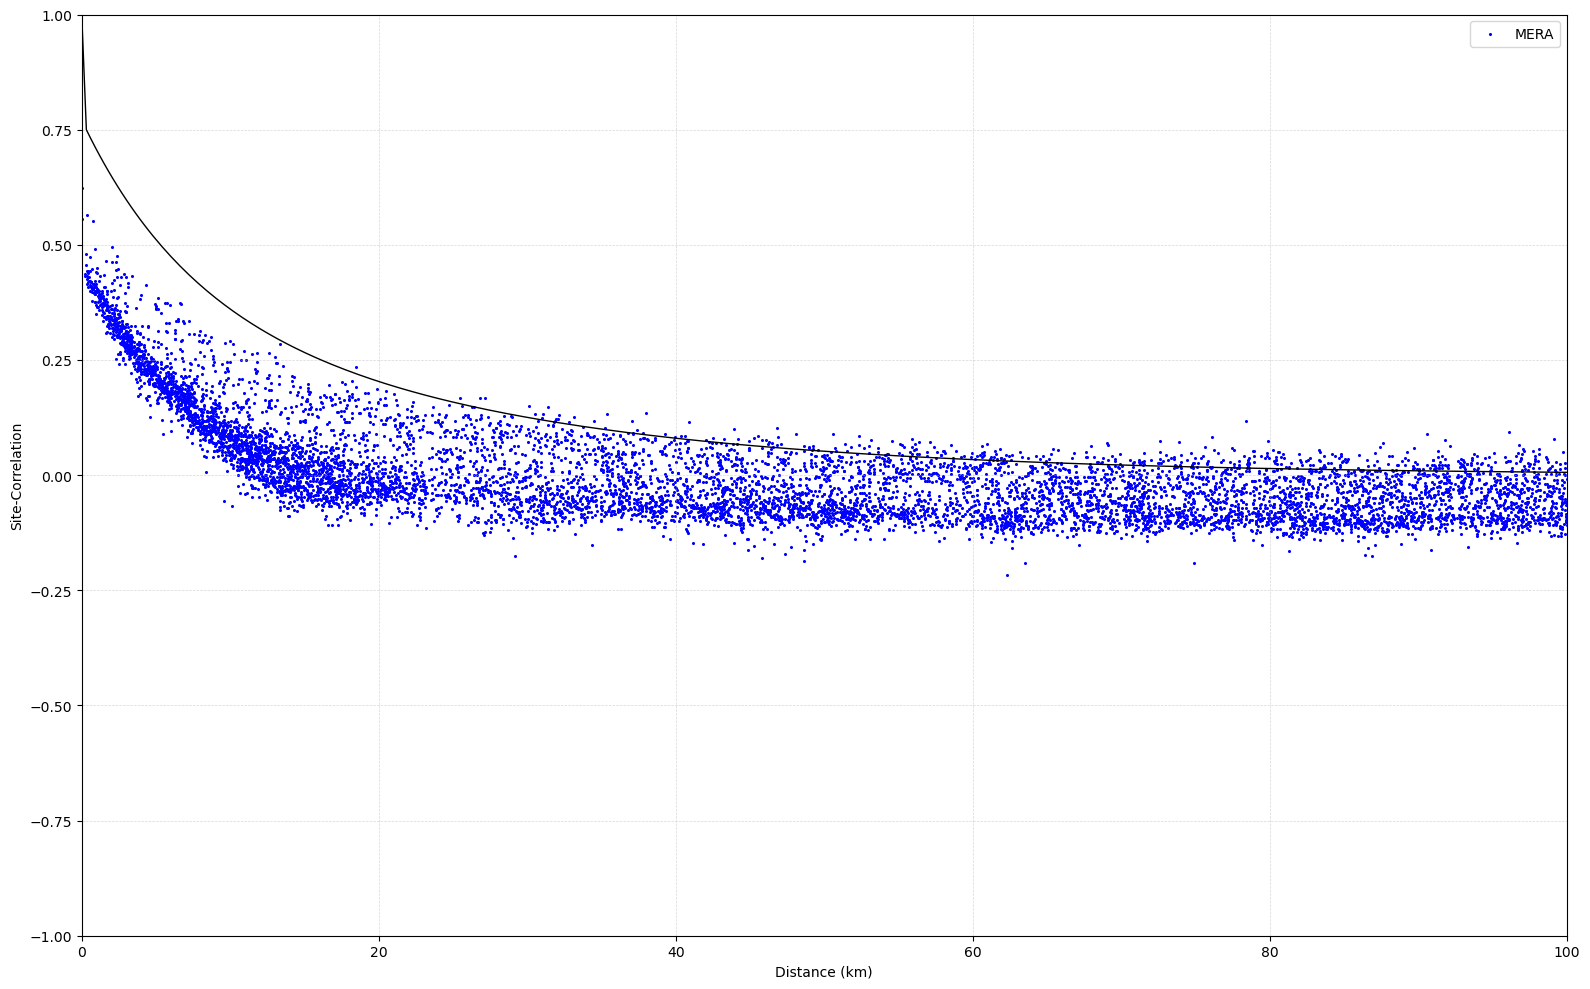

In [50]:
plot_corr(mera_site_corr_df, cur_dist_matrix, mask)

## Total Approach for spatial correlation calculation
Assumes that the between-event is zero and the total residual is the within-event term.

In [51]:
total_site_corr_dir = emp_rel_dir / "total" / "rel_site_correlations"

total_site_corr_df = pd.read_csv(total_site_corr_dir / f"{cur_im}.csv", index_col=0)
total_site_corr_df = total_site_corr_df.pivot(index="site_1", columns="site_2", values="corr")

In [52]:
assert cur_dist_matrix.index.equals(total_site_corr_df.index)
assert cur_dist_matrix.columns.equals(total_site_corr_df.columns)

mask = np.tril(cur_dist_matrix.values).astype(bool)

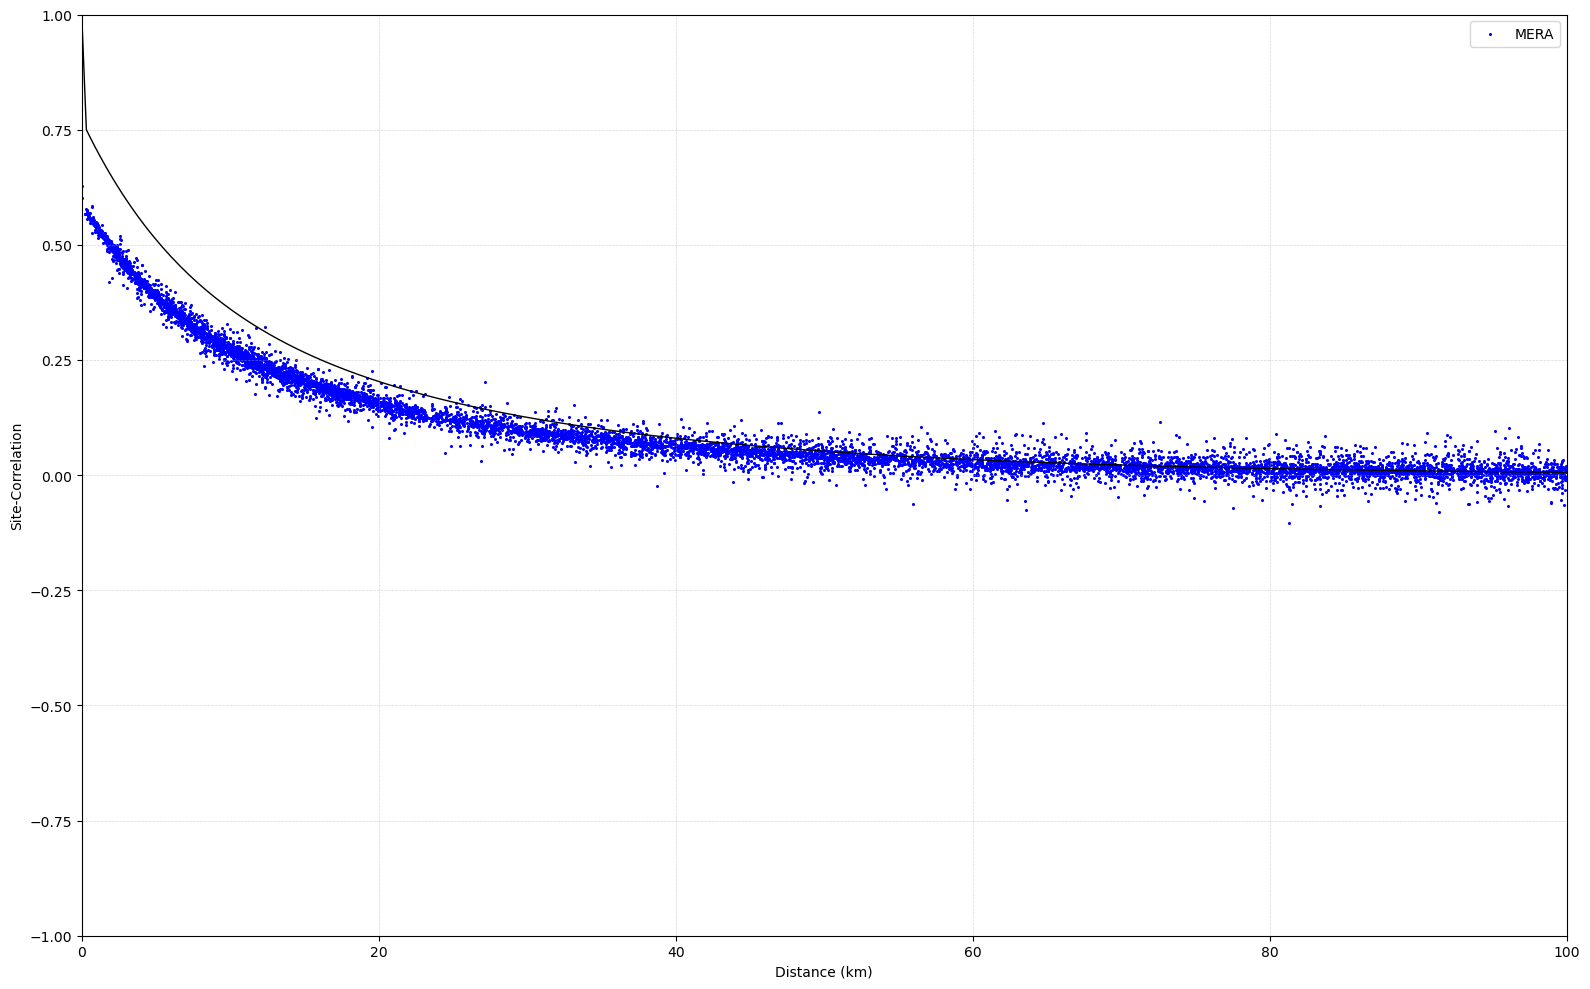

In [53]:
plot_corr(total_site_corr_df, cur_dist_matrix, mask)